# 05b รอบที่ 2: ราคาวัตถุดิบเฉพาะสินค้า (เชิงสำรวจ)

> **สถานะ:** ทำหลังเปิดผลช่วง test ในขั้น 05 แล้ว ผลทั้งหมดใน notebook นี้เป็น **เชิงสำรวจ** ไม่ใช้แทนข้อสรุปของการเปรียบเทียบหลักในขั้น 05 (Scope หัวข้อ 24)

ขั้น 05 พบว่าค่าเงินและ Brent ไม่ช่วยพยากรณ์ IMI อย่างมีนัยสำคัญ ตามวงจร CRISP-DM จึงย้อนกลับไปขั้น Data Understanding และ Data Preparation เพื่อทดสอบว่าราคาวัตถุดิบโลกของสินค้านั้นโดยตรงช่วยได้หรือไม่

**การออกแบบที่ล็อกไว้ใน Scope ก่อนรัน:**
- **ปุ๋ย (318):** Urea และ DAP จาก World Bank Pink Sheet
- **นม (402):** FAO Dairy Price Index
- **feature:** โครงสร้างเดียวกับ Brent คือ log change 1/2/3 เดือน, volatility 6 เดือน และ lead t+1
- **feature set:** `3+commodity` = ชุด 3 + feature ใหม่
- **โมเดล:** Ridge เท่านั้น ใช้ rolling origin, กฎ training set และ alpha grid เดียวกับขั้น 04
- **การเปรียบเทียบที่กำหนดไว้:** Ridge `3+commodity` เทียบ Ridge `3` ที่ h=3 กลุ่มละ 1 ข้อ

In [1]:
from __future__ import annotations
import hashlib, json, sys, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, Pretty, display
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from tqdm.std import tqdm as _tqdm

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'PROJECT_SCOPE.md').exists())
RAW_DIR, PROCESSED_DIR = ROOT / 'data/raw', ROOT / 'data/processed'
METRICS_DIR, FIGURES_DIR = ROOT / 'logs/metrics', ROOT / 'reports/figures'
VALIDATION_START, TEST_START = pd.Timestamp('2015-01-01'), pd.Timestamp('2019-01-01')
ALPHAS = np.logspace(-2, 5, 15)            # grid เดียวกับขั้น 04
PRIMARY_H, ALPHA_WARN = 3, 0.10
PUBLICATION_DAY_ASSUMED = 10              # ค่ารายเดือนของเดือน m ถือว่าเผยแพร่ไม่เกินวันที่ 10 ของเดือน m+1
COMMODITY_SERIES = {'318': {'urea': ('wb-pinksheet', 'Urea'), 'dap': ('wb-pinksheet', 'DAP')},
                    '402': {'fao_dairy': ('fao-ffpi', 'Dairy')}}
GROUP_LABEL = {'318': 'Fertilizer (318)', '402': 'Dairy (402)'}
SERIES_COLORS = {'ridge/3': '#2a78d6', 'ridge/3+commodity': '#eb6834'}
INK, MUTED = '#2b2b2b', '#8a8a85'

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''): digest.update(chunk)
    return digest.hexdigest()

class _DisplayLine:
    def __init__(self): self.handle = display(Pretty(''), display_id=True)
    def write(self, text):
        text = text.replace('\r', '').strip()
        if text: self.handle.update(Pretty(text))
    def flush(self): pass

def tqdm(*args, **kwargs):
    in_kernel = get_ipython() is not None and hasattr(get_ipython(), 'kernel')
    kwargs.setdefault('file', _DisplayLine() if in_kernel else sys.stdout)
    kwargs.setdefault('mininterval', 1.0); kwargs.setdefault('ncols', 110)
    return _tqdm(*args, **kwargs)

manifest = pd.read_csv(METRICS_DIR / '03_processed_manifest.csv')
assert sha256(ROOT / manifest.loc[0, 'file']) == manifest.loc[0, 'sha256']
modeling = pd.read_csv(ROOT / manifest.loc[0, 'file'], dtype={'commodity_code': str},
                       parse_dates=['month_ce', 'forecast_origin', 'target_month', 'target_available_date'])
feature_sets = pd.read_csv(METRICS_DIR / '03_feature_sets.csv', dtype={'feature_set': str})
SET3 = feature_sets.set_index('feature_set').loc['3', 'features'].split('|')
run04 = pd.read_csv(METRICS_DIR / '04_run_manifest.csv')
assert sha256(ROOT / run04.loc[0, 'file']) == run04.loc[0, 'sha256']
pred04 = pd.read_csv(ROOT / run04.loc[0, 'file'], dtype={'commodity_code': str, 'feature_set': str},
                     parse_dates=['month_ce', 'forecast_origin'])
pred04['series'] = pred04.model + '/' + pred04.feature_set
print(f'modeling_table {len(modeling):,} แถว; ค่าทำนายขั้น 04 {len(pred04):,} แถว; ชุด 3 มี {len(SET3)} features')

modeling_table 4,560 แถว; ค่าทำนายขั้น 04 28,560 แถว; ชุด 3 มี 16 features


## 1. Data Understanding: ราคาวัตถุดิบโลก

อ่านไฟล์จาก `sources.json` และตรวจ SHA-256 ก่อนใช้ ข้อมูลจาก Pink Sheet และ FAO เป็นค่ารายเดือนอยู่แล้ว จึงไม่ต้องเฉลี่ยจากข้อมูลรายวันแบบ FRED

,series,start,end,months,mean_abs_log_change_1m_pct
0,urea,1999-01-01,2026-09-01,333,8.146
1,dap,1999-01-01,2026-09-01,333,4.524
2,fao_dairy,1999-01-01,2026-09-01,333,2.629


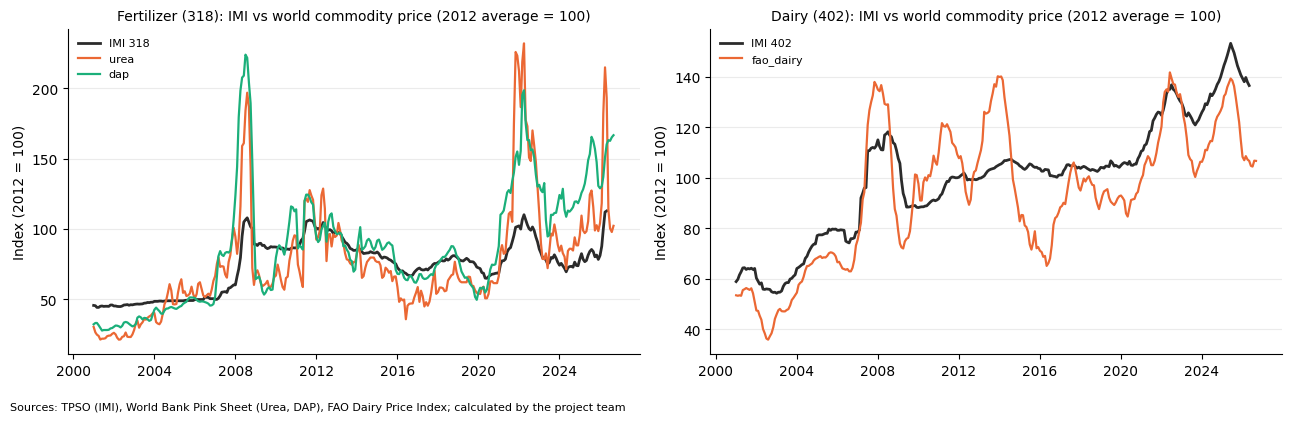

In [2]:
sources = json.loads((RAW_DIR / 'sources.json').read_text(encoding='utf-8'))['sources']
def latest(prefix): return next(x for x in reversed(sources) if x['source_id'].startswith(prefix))

def load_pinksheet(path):
    sheet = pd.read_excel(path, sheet_name='Monthly Prices', header=None)
    names = [str(x).strip() if pd.notna(x) else '' for x in sheet.iloc[4]]
    frame = sheet.iloc[6:, [0, names.index('Urea'), names.index('DAP')]].copy()
    frame.columns = ['period', 'Urea', 'DAP']
    frame = frame[frame.period.astype(str).str.match(r'^\d{4}M\d{2}$')]
    frame['month_ce'] = pd.to_datetime(frame.period.str.replace('M', '-') + '-01')
    return frame.set_index('month_ce')[['Urea', 'DAP']].apply(pd.to_numeric, errors='coerce')

def load_fao(path):
    lines = Path(path).read_text(encoding='utf-8-sig').splitlines()
    header = next(i for i, line in enumerate(lines) if line.startswith('Date,'))
    frame = pd.read_csv(path, skiprows=header, encoding='utf-8-sig').dropna(subset=['Date'])
    frame = frame[frame.Date.astype(str).str.match(r'^\d{4}-\d{2}$')]
    frame['month_ce'] = pd.to_datetime(frame.Date + '-01')
    return frame.set_index('month_ce')[['Dairy']].apply(pd.to_numeric, errors='coerce')

raw_frames = {}
for key, loader in (('wb-pinksheet', load_pinksheet), ('fao-ffpi', load_fao)):
    record = latest(f'{key}-monthly-')
    assert sha256(RAW_DIR / record['file']) == record['sha256'], record['file']
    raw_frames[key] = loader(RAW_DIR / record['file'])

monthly = {}
for g, spec in COMMODITY_SERIES.items():
    for name, (key, column) in spec.items():
        series = raw_frames[key][column]
        series = series[series.index >= '1999-01-01'].asfreq('MS')
        assert series.notna().all() and (series > 0).all(), name
        monthly[name] = series
summary = pd.DataFrame([{'series': n, 'start': s.index.min().date(), 'end': s.index.max().date(), 'months': len(s),
                         'mean_abs_log_change_1m_pct': (100 * np.log(s).diff()).abs().mean()} for n, s in monthly.items()])
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, g in zip(axes, COMMODITY_SERIES):
    imi = modeling[(modeling.commodity_code == g) & (modeling.horizon == PRIMARY_H)].set_index('month_ce').imi_index
    axis.plot(imi.index, 100 * imi / imi.loc['2012-01-01':'2012-12-01'].mean(), color=INK, linewidth=2, label=f'IMI {g}')
    for i, name in enumerate(COMMODITY_SERIES[g]):
        s = monthly[name].loc['2001-01-01':]
        axis.plot(s.index, 100 * s / s.loc['2012-01-01':'2012-12-01'].mean(), linewidth=1.6,
                  color=['#eb6834', '#1baf7a'][i], label=name)
    axis.set_title(f'{GROUP_LABEL[g]}: IMI vs world commodity price (2012 average = 100)', fontsize=10)
    axis.set_ylabel('Index (2012 = 100)'); axis.grid(axis='y', alpha=0.25); axis.legend(frameon=False, fontsize=8)
    for side in ('top', 'right'): axis.spines[side].set_visible(False)
fig.text(0.01, 0.01, 'Sources: TPSO (IMI), World Bank Pink Sheet (Urea, DAP), FAO Dairy Price Index; calculated by the project team', fontsize=8)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIGURES_DIR / '05b_commodity_vs_imi.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. Data Preparation: feature และ availability

feature ของแต่ละ series ใช้โครงสร้างเดียวกับ Brent:
- log change 1, 2, 3 เดือนถึงเดือน t
- volatility 6 เดือน
- lead t+1 = log X[t+1] − log X[t]

**availability:** สมมติว่าค่ารายเดือนของเดือน t+1 เผยแพร่ไม่เกินวันที่ 10 ของเดือน t+2 ซึ่งก่อน forecast origin วันที่ 15
- ปฏิทิน FAO ปี 2026 เผยแพร่วันที่ 2–9 และไฟล์ Pink Sheet ล่าสุดปรับปรุงวันที่ 2 ต.ค. 2026
- วันเผยแพร่ย้อนหลังและการปรับแก้ค่าย้อนหลัง [ยังไม่ยืนยัน]

In [3]:
def commodity_features(name, series):
    log_s = np.log(series)
    f = pd.DataFrame(index=series.index)
    for w in (1, 2, 3): f[f'{name}_log_change_{w}m_pct'] = 100 * (log_s - log_s.shift(w))
    f[f'{name}_volatility_6m_pct'] = (100 * log_s.diff()).rolling(6, min_periods=6).std(ddof=1)
    f[f'{name}_lead_t1_pct'] = 100 * (log_s.shift(-1) - log_s)
    f[f'{name}_lead_t1_assumed_published'] = (series.index + pd.offsets.MonthBegin(2) + pd.Timedelta(days=PUBLICATION_DAY_ASSUMED - 1))
    return f

panels, NEW_FEATURES = {}, {}
for g, spec in COMMODITY_SERIES.items():
    base = modeling[modeling.commodity_code == g].copy()
    new_cols = []
    for name in spec:
        f = commodity_features(name, monthly[name])
        new_cols += [c for c in f.columns if not c.endswith('_assumed_published')]
        base = base.merge(f.reset_index().rename(columns={'index': 'month_ce'}), on='month_ce', how='left', validate='many_to_one')
        published = base[f'{name}_lead_t1_assumed_published']
        assert (published < base.forecast_origin).all(), f'{name}: lead t+1 ยังไม่เผยแพร่ ณ origin'
    assert base[new_cols].notna().all().all(), 'feature ใหม่มีค่าว่าง'
    NEW_FEATURES[g] = new_cols
    for h, panel in base.groupby('horizon'):
        panels[(g, int(h))] = panel.sort_values('month_ce').reset_index(drop=True)
feature_table = pd.DataFrame([{'commodity_code': g, 'feature_set': '3+commodity', 'n_features': len(SET3) + len(c),
                               'new_features': '|'.join(c)} for g, c in NEW_FEATURES.items()])
feature_table.to_csv(METRICS_DIR / '05b_feature_sets.csv', index=False)
display(feature_table)

,commodity_code,feature_set,n_features,new_features
0,318,3+commodity,26,urea_log_change_1m_pct|urea_log_change_2m_pct|...
1,402,3+commodity,21,fao_dairy_log_change_1m_pct|fao_dairy_log_chan...


## 3. Modeling: Ridge `3+commodity` ด้วย rolling origin

ใช้กฎเดียวกับขั้น 04 ทุกประการ
- training set คือแถวที่ `target_available_date ≤ forecast_origin`
- scaler fit ใหม่ทุก origin
- เลือก alpha จาก MAE ช่วง validation แล้วตรึงไว้ใช้ในช่วง test

In [4]:
def training_rows(panel, row):
    train = panel[panel.target_available_date <= row.forecast_origin]
    assert train.month_ce.max() <= row.month_ce - pd.DateOffset(months=int(row.horizon))
    return train

def fit_predict(train, row, features, alphas):
    scaler = StandardScaler().fit(train[features])
    x_train, x_row = scaler.transform(train[features]), scaler.transform(row[features].to_frame().T.astype(float))
    return [float(Ridge(alpha=a).fit(x_train, train.target_y_pct).predict(x_row)[0]) for a in alphas]

parts, alpha_rows = [], []
bar = tqdm(total=len(panels), desc='Ridge 3+commodity', unit='กลุ่ม×h')
for (g, h), panel in panels.items():
    features = SET3 + NEW_FEATURES[g]
    val_rows = panel[(panel.month_ce >= VALIDATION_START) & (panel.month_ce < TEST_START)]
    test_rows = panel[panel.month_ce >= TEST_START]
    val_preds = np.array([fit_predict(training_rows(panel, r), r, features, ALPHAS) for _, r in val_rows.iterrows()])
    val_mae = np.abs(val_preds - val_rows.target_y_pct.to_numpy()[:, None]).mean(axis=0)
    best = max(i for i in range(len(ALPHAS)) if np.isclose(val_mae[i], val_mae.min()))
    alpha_rows += [{'commodity_code': g, 'horizon': h, 'alpha': a, 'validation_mae': m, 'selected': i == best}
                   for i, (a, m) in enumerate(zip(ALPHAS, val_mae))]
    test_preds = [fit_predict(training_rows(panel, r), r, features, [ALPHAS[best]])[0] for _, r in test_rows.iterrows()]
    rows = pd.concat([val_rows, test_rows])
    parts.append(pd.DataFrame({'commodity_code': g, 'horizon': h, 'month_ce': rows.month_ce.values,
                               'split': np.where(rows.month_ce < TEST_START, 'validation', 'test'),
                               'y_true': rows.target_y_pct.values, 'series': 'ridge/3+commodity',
                               'alpha': ALPHAS[best], 'y_pred': np.concatenate([val_preds[:, best], test_preds])}))
    bar.set_postfix(group=g, h=h); bar.update(1)
bar.close()
pred2 = pd.concat(parts, ignore_index=True)
alphas = pd.DataFrame(alpha_rows)
alphas.to_csv(METRICS_DIR / '05b_ridge_alpha_selection.csv', index=False)
sel = alphas[alphas.selected]
print(f"alpha ที่เลือก: {sorted(sel.alpha.round(3).unique())}; ชนขอบบน {int(np.isclose(sel.alpha, ALPHAS.max()).sum())} จาก {len(sel)}")

compare = pred04[pred04.commodity_code.isin(COMMODITY_SERIES) & pred04.series.isin(['ridge/3', 'no_change/none'])]
pred_all = pd.concat([compare[['commodity_code', 'horizon', 'month_ce', 'split', 'y_true', 'series', 'y_pred',
                               'high_risk_threshold']], pred2.merge(
    compare.loc[compare.series == 'no_change/none', ['commodity_code', 'horizon', 'month_ce', 'high_risk_threshold', 'y_true']],
    on=['commodity_code', 'horizon', 'month_ce'], suffixes=('', '_04'), validate='one_to_one')], ignore_index=True)
assert np.allclose(pred_all.dropna(subset=['y_true_04']).y_true, pred_all.dropna(subset=['y_true_04']).y_true_04)
pred_all = pred_all.drop(columns=['y_true_04', 'alpha'], errors='ignore')
pred_all['error'] = pred_all.y_pred - pred_all.y_true
counts = pred_all.groupby(['commodity_code', 'horizon', 'series']).size().unstack()
assert (counts.nunique(axis=1) == 1).all(), 'จำนวน origin ไม่เท่ากันระหว่าง series'
pred_all.to_csv(METRICS_DIR / '05b_predictions.csv', index=False)
print(f'ค่าทำนายรอบที่ 2: {len(pred2):,} แถว; ตารางเทียบรวม {len(pred_all):,} แถว')

Ridge 3+commodity: 100%|#################################| 10/10 [00:04<00:00,  2.14กลุ่ม×h/s, group=402, h=6]

alpha ที่เลือก: [np.float64(316.228), np.float64(3162.278)]; ชนขอบบน 0 จาก 10
ค่าทำนายรอบที่ 2: 1,360 แถว; ตารางเทียบรวม 4,080 แถว


## 4. Evaluation (เชิงสำรวจ)

**การเปรียบเทียบที่กำหนดไว้:** Ridge `3+commodity` เทียบ Ridge `3` ที่ h=3 ใช้ DM-HLN แบบเดียวกับขั้น 05 รายงาน p-value โดยไม่อ้างนัยสำคัญยืนยัน

ผลเพิ่มเติม:
- MAE ช่วง validation และ test
- skill เทียบ No-change ที่ h=2–6
- alert metrics ที่ h=3

In [5]:
def dm_hln(e1, e2, h):
    d = np.abs(np.asarray(e1)) - np.abs(np.asarray(e2)); n, dbar = len(d), d.mean(); dc = d - dbar
    gamma = np.array([np.sum(dc[k:] * dc[:n - k]) / n for k in range(h)])
    var, method = (gamma[0] + 2 * gamma[1:].sum()) / n, 'acf'
    if var <= 0:
        var = (gamma[0] + 2 * ((1 - np.arange(1, h) / h) * gamma[1:]).sum()) / n
        method = 'bartlett'
    stat = dbar / np.sqrt(var) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return stat, 2 * stats.t.sf(abs(stat), df=n - 1), method

def errors(split, g, h, series):
    return pred_all[(pred_all.split == split) & (pred_all.commodity_code == g) & (pred_all.horizon == h)
                    & (pred_all.series == series)].sort_values('month_ce').error.values

rows = []
for g in COMMODITY_SERIES:
    for h in sorted(pred_all.horizon.unique()):
        new, old, nc = (errors('test', g, h, s) for s in ('ridge/3+commodity', 'ridge/3', 'no_change/none'))
        dm_old, p_old, variance_old = dm_hln(new, old, h)
        dm_nc, p_nc, variance_nc = dm_hln(new, nc, h)
        rows.append({'commodity_code': g, 'horizon': h, 'n_test': len(new),
                     'val_MAE_3+commodity': np.abs(errors('validation', g, h, 'ridge/3+commodity')).mean(),
                     'val_MAE_ridge3': np.abs(errors('validation', g, h, 'ridge/3')).mean(),
                     'test_MAE_3+commodity': np.abs(new).mean(), 'test_MAE_ridge3': np.abs(old).mean(),
                     'test_MAE_no_change': np.abs(nc).mean(),
                     'change_vs_ridge3_pct': 100 * (np.abs(new).mean() / np.abs(old).mean() - 1),
                     'dm_vs_ridge3': dm_old, 'p_vs_ridge3': p_old,
                     'variance_method_vs_ridge3': variance_old, 'variance_method_vs_no_change': variance_nc,
                     'skill_vs_no_change': 1 - np.abs(new).mean() / np.abs(nc).mean(), 'p_vs_no_change': p_nc,
                     'skill_ridge3_vs_no_change': 1 - np.abs(old).mean() / np.abs(nc).mean(),
                     'prespecified': h == PRIMARY_H})
results = pd.DataFrame(rows)
results.to_csv(METRICS_DIR / '05b_results.csv', index=False)
display(results[results.prespecified].round(4).T)
display(results[['commodity_code', 'horizon', 'test_MAE_3+commodity', 'test_MAE_ridge3', 'test_MAE_no_change',
                 'skill_vs_no_change', 'p_vs_no_change', 'skill_ridge3_vs_no_change']].round(3))

def alert_scores(frame):
    event, alert = frame.y_true > frame.high_risk_threshold, frame.y_pred > frame.high_risk_threshold
    tp, fp, fn = (event & alert).sum(), (~event & alert).sum(), (event & ~alert).sum()
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = tp / (tp + fn) if tp + fn else np.nan
    denominator = 2 * tp + fp + fn
    f1 = 2 * tp / denominator if denominator else np.nan
    return {'events': int(event.sum()), 'alerts': int(alert.sum()), 'TP': int(tp), 'precision': precision, 'recall': recall, 'F1': f1}
alerts = pd.DataFrame([{'commodity_code': g, 'series': s, **alert_scores(pred_all[(pred_all.split == 'test') & (pred_all.commodity_code == g)
                         & (pred_all.horizon == PRIMARY_H) & (pred_all.series == s)])}
                       for g in COMMODITY_SERIES for s in ('ridge/3+commodity', 'ridge/3')])
alerts.to_csv(METRICS_DIR / '05b_alert_metrics.csv', index=False)
display(alerts.round(3))

,1,6
commodity_code,318,402
horizon,3,3
n_test,89,89
val_MAE_3+commodity,2.2897,1.2312
val_MAE_ridge3,2.18,1.1439
test_MAE_3+commodity,5.947,2.1706
test_MAE_ridge3,6.3673,2.1988
test_MAE_no_change,6.4759,2.5408
change_vs_ridge3_pct,-6.6003,-1.2831
dm_vs_ridge3,-2.3271,-0.7061


,commodity_code,horizon,test_MAE_3+commodity,test_MAE_ridge3,test_MAE_no_change,skill_vs_no_change,p_vs_no_change,skill_ridge3_vs_no_change
0,318,2,4.152,4.630,4.886,0.150,0.012,0.052
1,318,3,5.947,6.367,6.476,0.082,0.135,0.017
2,318,4,7.356,7.651,7.615,0.034,0.644,-0.005
3,318,5,8.546,8.651,8.479,-0.008,0.926,-0.020
4,318,6,9.840,10.101,9.598,-0.025,0.780,-0.052
5,402,2,1.577,1.589,1.821,0.134,0.011,0.128
6,402,3,2.171,2.199,2.541,0.146,0.033,0.135
7,402,4,2.788,2.891,3.298,0.155,0.045,0.123
8,402,5,3.355,3.504,3.992,0.159,0.073,0.122
9,402,6,3.964,4.121,4.617,0.141,0.156,0.107


,commodity_code,series,events,alerts,TP,precision,recall,F1
0,318,ridge/3+commodity,34,26,17,0.654,0.500,0.567
1,318,ridge/3,34,24,13,0.542,0.382,0.448
2,402,ridge/3+commodity,29,0,0,NaN,0.000,0.000
3,402,ridge/3,29,0,0,NaN,0.000,0.000


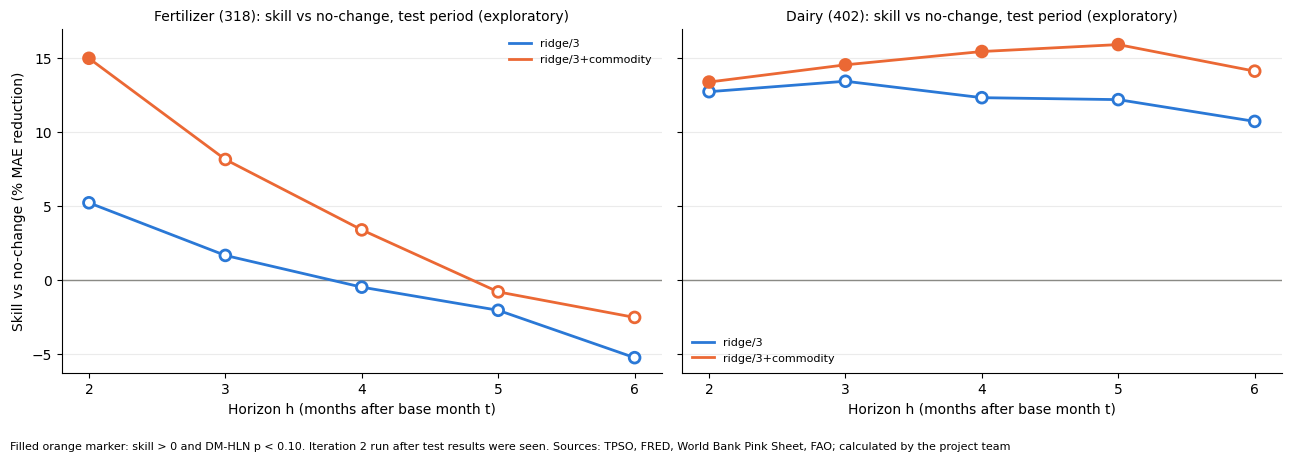

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for axis, g in zip(axes, COMMODITY_SERIES):
    frame = results[results.commodity_code == g]
    axis.axhline(0, color=MUTED, linewidth=1)
    for series, column, p_col in (('ridge/3', 'skill_ridge3_vs_no_change', None),
                                   ('ridge/3+commodity', 'skill_vs_no_change', 'p_vs_no_change')):
        axis.plot(frame.horizon, 100 * frame[column], color=SERIES_COLORS[series], linewidth=2, label=series)
        filled = (frame[column] > 0) & (frame[p_col] < ALPHA_WARN) if p_col else pd.Series(False, index=frame.index)
        axis.scatter(frame.horizon, 100 * frame[column], s=60, edgecolors=SERIES_COLORS[series], linewidths=2, zorder=3,
                     facecolors=[SERIES_COLORS[series] if f else 'white' for f in filled])
    axis.set_title(f'{GROUP_LABEL[g]}: skill vs no-change, test period (exploratory)', fontsize=10)
    axis.set_xlabel('Horizon h (months after base month t)'); axis.set_xticks(sorted(frame.horizon))
    axis.grid(axis='y', alpha=0.25); axis.legend(frameon=False, fontsize=8)
    for side in ('top', 'right'): axis.spines[side].set_visible(False)
axes[0].set_ylabel('Skill vs no-change (% MAE reduction)')
fig.text(0.01, 0.01, 'Filled orange marker: skill > 0 and DM-HLN p < 0.10. Iteration 2 run after test results were seen. '
         'Sources: TPSO, FRED, World Bank Pink Sheet, FAO; calculated by the project team', fontsize=8)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIGURES_DIR / '05b_skill_iteration2.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. สรุปรอบที่ 2

ข้อความด้านล่างสร้างจากตัวเลขในตาราง และใช้การตีความตามที่ล็อกไว้ใน Scope หัวข้อ 24

In [7]:
lines = ['**การเปรียบเทียบที่กำหนดไว้ (h=3, เชิงสำรวจ):**']
for g in COMMODITY_SERIES:
    r = results[(results.commodity_code == g) & results.prespecified].iloc[0]
    word = 'ลดลง' if r.change_vs_ridge3_pct < 0 else 'เพิ่มขึ้น'
    lines.append(f"- {GROUP_LABEL[g]}: MAE ของ 3+commodity {r['test_MAE_3+commodity']:.3f} เทียบชุด 3 {r.test_MAE_ridge3:.3f} "
                 f"({word} {abs(r.change_vs_ridge3_pct):.1f}%, DM-HLN p = {r.p_vs_ridge3:.3f}); "
                 f"validation {r['val_MAE_3+commodity']:.3f} เทียบ {r.val_MAE_ridge3:.3f}")
lines.append('\n**skill เทียบ No-change ช่วง test (h=2–6):**')
for g in COMMODITY_SERIES:
    frame = results[results.commodity_code == g]
    lines.append(f"- {GROUP_LABEL[g]}: 3+commodity " + ', '.join(f"{100 * s:+.1f}%" for s in frame.skill_vs_no_change)
                 + "; ชุด 3 " + ', '.join(f"{100 * s:+.1f}%" for s in frame.skill_ridge3_vs_no_change))
lines.append('\nผลนี้เป็นเชิงสำรวจหลังเห็นผล test ไม่เปลี่ยนข้อสรุปหลักของขั้น 05')
display(Markdown('\n'.join(lines)))

**การเปรียบเทียบที่กำหนดไว้ (h=3, เชิงสำรวจ):**
- Fertilizer (318): MAE ของ 3+commodity 5.947 เทียบชุด 3 6.367 (ลดลง 6.6%, DM-HLN p = 0.022); validation 2.290 เทียบ 2.180
- Dairy (402): MAE ของ 3+commodity 2.171 เทียบชุด 3 2.199 (ลดลง 1.3%, DM-HLN p = 0.482); validation 1.231 เทียบ 1.144

**skill เทียบ No-change ช่วง test (h=2–6):**
- Fertilizer (318): 3+commodity +15.0%, +8.2%, +3.4%, -0.8%, -2.5%; ชุด 3 +5.2%, +1.7%, -0.5%, -2.0%, -5.2%
- Dairy (402): 3+commodity +13.4%, +14.6%, +15.5%, +15.9%, +14.1%; ชุด 3 +12.8%, +13.5%, +12.3%, +12.2%, +10.7%

ผลนี้เป็นเชิงสำรวจหลังเห็นผล test ไม่เปลี่ยนข้อสรุปหลักของขั้น 05

In [8]:
log_path = ROOT / 'logs/process_log.md'
log = log_path.read_text(encoding='utf-8')
marker = 'ขั้นตอน: 05b รอบที่ 2 ราคาวัตถุดิบเฉพาะสินค้า'
if marker not in log:
    def line(g):
        r = results[(results.commodity_code == g) & results.prespecified].iloc[0]
        return (f"{GROUP_LABEL[g]} MAE {r['test_MAE_3+commodity']:.3f} เทียบชุด 3 {r.test_MAE_ridge3:.3f} "
                f"({r.change_vs_ridge3_pct:+.1f}%, p = {r.p_vs_ridge3:.3f})")
    skills = '; '.join(f"{GROUP_LABEL[g]}: " + ', '.join(f"h{int(r.horizon)} {100 * r.skill_vs_no_change:+.1f}%"
                       for r in results[results.commodity_code == g].itertuples()) for g in COMMODITY_SERIES)
    entry = f"""

## [2026-10-05] {marker}
**สิ่งที่ทำ:** เพิ่ม feature ราคา Urea และ DAP (World Bank Pink Sheet) ให้กลุ่มปุ๋ย และ FAO Dairy Price Index ให้กลุ่มนม ด้วยโครงสร้างเดียวกับ Brent แล้วรัน Ridge `3+commodity` แบบ rolling origin ตามการออกแบบที่ล็อกไว้ใน Scope หัวข้อ 24 ทำหลังเปิดผล test จึงเป็นผลเชิงสำรวจ

**ผลที่ได้:**
- การเปรียบเทียบที่กำหนดไว้ (h=3): {line('318')}; {line('402')}
- skill เทียบ No-change ช่วง test: {skills}
- ไฟล์: logs/metrics/05b_*.csv และ reports/figures/05b_*.png

**สิ่งที่พบ / ปัญหา:** วันเผยแพร่ย้อนหลังและการปรับแก้ค่าย้อนหลังของ Pink Sheet และ FAO ยังไม่ยืนยัน จึงใช้สมมติฐานว่าค่าของเดือน t+1 เผยแพร่ไม่เกินวันที่ 10 ของเดือน t+2

**การตัดสินใจและเหตุผล:** รายงานตามการเปรียบเทียบที่กำหนดไว้เท่านั้น ไม่ลองชุด feature อื่นเพิ่ม และไม่เปลี่ยนข้อสรุปหลักของขั้น 05

**ขั้นต่อไป:** 06 Deployment (dashboard)
"""
    log_path.write_text(log.rstrip() + entry + '\n', encoding='utf-8')
    print('บันทึกผลลง logs/process_log.md แล้ว')
else:
    print('มีรายการรอบที่ 2 ใน process log แล้ว จึงไม่บันทึกซ้ำ')

มีรายการรอบที่ 2 ใน process log แล้ว จึงไม่บันทึกซ้ำ
